In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree,DecisionTreeClassifier
from sklearn.metrics import f1_score

# Data Preprocessing

In [48]:
#extracting the data from datasets folder
shop=pd.read_csv("datasets/shop_smart_ecommerce.csv")

In [49]:
# getting some data analysis from the data 
print(shop.info())
print(shop.describe())
print(shop.shape)
print(shop.isnull().sum())

shop.sample(6)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
2608,9,118.0,2,10.0,16,401.950000,0.004762,0.013016,0.000000,0.0,May,1,1,1,3,Returning_Visitor,False,False
7566,5,46.5,0,0.0,94,1729.716667,0.005051,0.025421,6.322600,0.0,Aug,2,2,8,1,Returning_Visitor,False,False
7215,0,0.0,1,217.6,77,1690.489222,0.011842,0.027847,0.000000,0.0,Sep,3,2,6,1,Returning_Visitor,True,False
4160,2,44.0,2,53.0,8,667.666667,0.000000,0.018182,56.623636,0.0,May,2,2,1,4,Returning_Visitor,True,True
11573,3,69.8,0,0.0,81,7514.790476,0.003821,0.021883,0.000000,0.0,Nov,2,2,1,2,Returning_Visitor,False,False
6688,3,106.6,0,0.0,11,203.980000,0.000000,0.004444,0.000000,0.0,Jul,2,2,1,3,New_Visitor,False,False


# Data visualisation

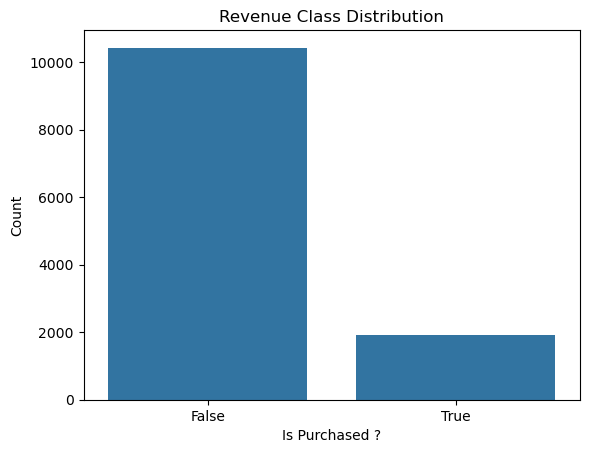

In [50]:
# target distribution plot for cheking comparisons

sns.countplot(x="Revenue",data=shop)

plt.title("Revenue Class Distribution")
plt.xlabel("Is Purchased ?")
plt.ylabel("Count")

plt.savefig("images/class_distribution.png")

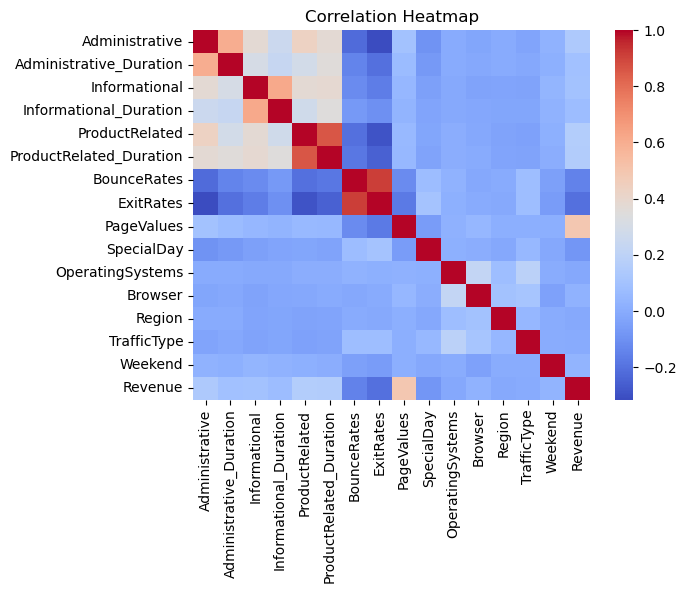

In [51]:
# Correlation heatmap for features 

sns.heatmap(shop.corr(numeric_only=True),
            cmap="coolwarm",
            annot=False)

plt.title("Correlation Heatmap")

plt.savefig("images/correlation_heatmap.png")

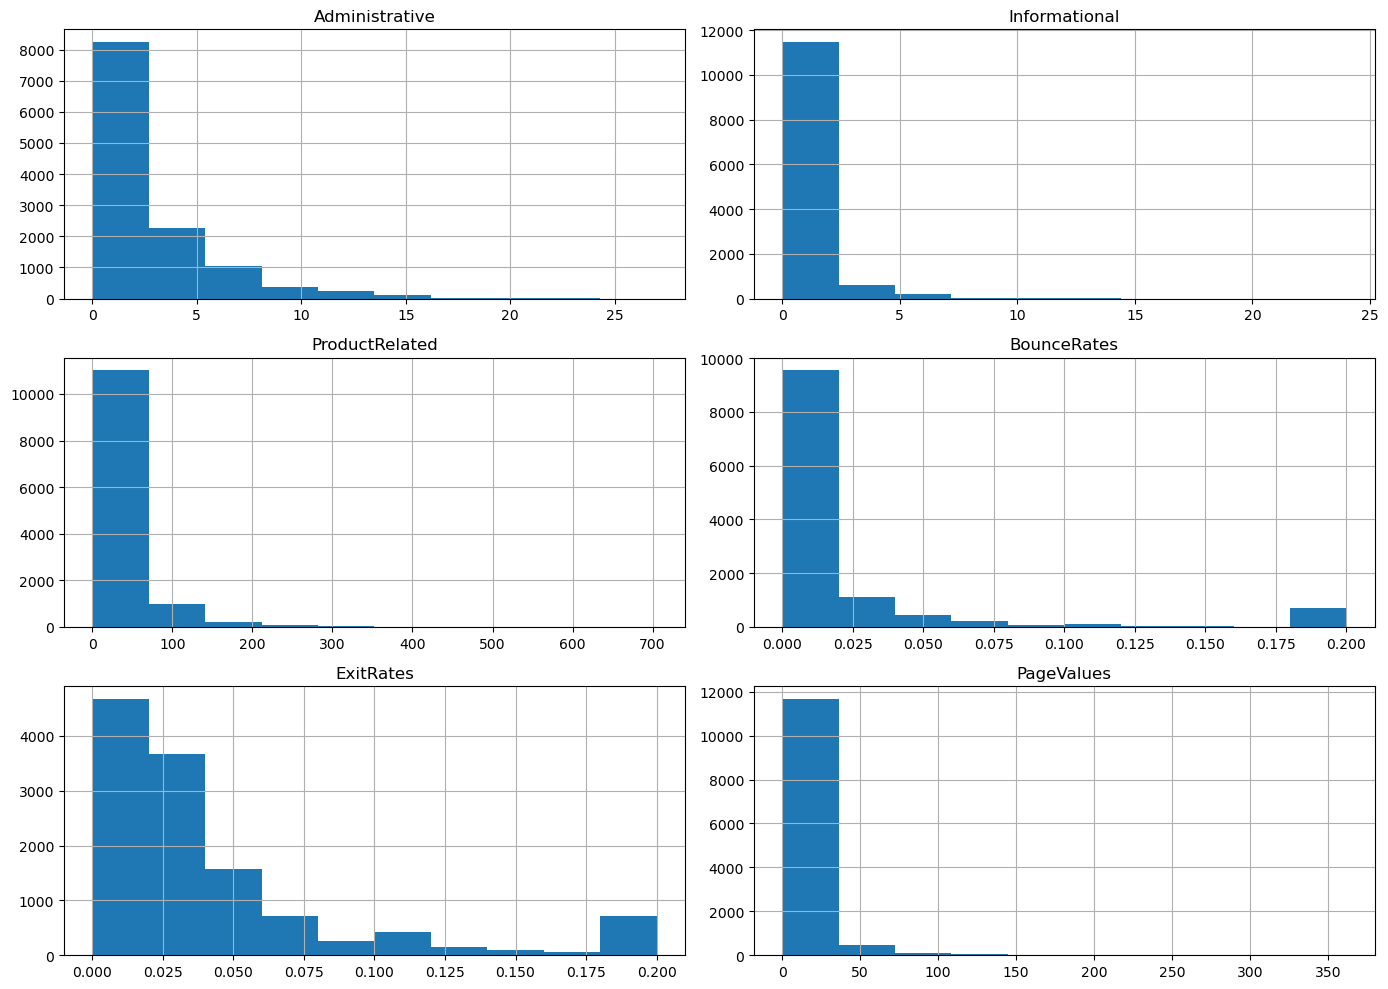

In [52]:
# histogram for selected Feature Distribution
numerical = ["Administrative","Informational","ProductRelated","BounceRates","ExitRates","PageValues"]

shop[numerical].hist(figsize=(14,10))

plt.tight_layout()

plt.savefig("images/feature_distribution.png")

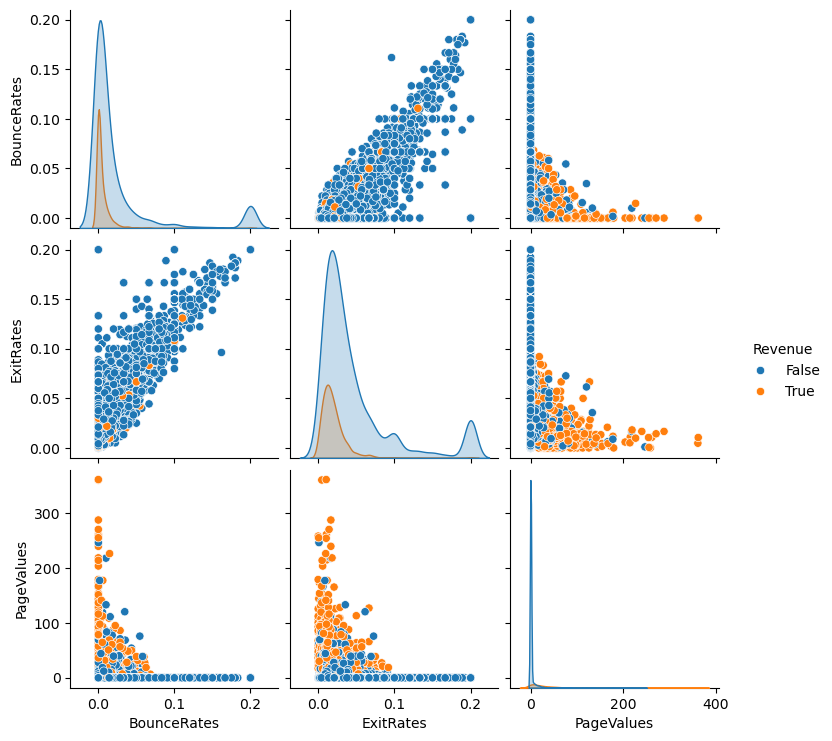

In [53]:
# Pair plot 
sns.pairplot(shop[["BounceRates","ExitRates","PageValues","Revenue"]],hue="Revenue")

plt.savefig("images/pairplot.png")

In [54]:
# label Encoding for string data

le=LabelEncoder()
shop["Month"]=le.fit_transform(shop["Month"])
shop["VisitorType"]=le.fit_transform(shop["VisitorType"])
shop["Weekend"]=le.fit_transform(shop["Weekend"])
shop["Revenue"]=le.fit_transform(shop["Revenue"])


shop["admin"]=shop["Administrative"] * shop["Administrative_Duration"]
shop["Infol"]= shop["Informational"] * shop["Informational_Duration"]
shop["ProductRelated"]= shop["ProductRelated"] * shop["ProductRelated_Duration"]

In [55]:
shop.sample(8)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,admin,Infol
361,0,0.000000,0,0.000000,1.992000e+03,166.000000,0.028571,0.071429,0.000000,0.0,5,2,2,1,1,2,1,0,0.000000,0.000000
4007,3,48.000000,0,0.000000,2.077538e+04,506.716667,0.004444,0.013968,10.485333,0.0,6,2,2,2,3,2,0,0,144.000000,0.000000
6190,12,217.649123,4,1009.733333,6.228464e+04,1639.069361,0.021739,0.031622,5.287006,0.0,9,3,2,6,1,2,1,0,2611.789474,4038.933332
6590,6,159.700000,1,72.600000,2.339568e+04,531.720000,0.000000,0.003922,0.000000,0.0,8,2,2,2,5,0,0,0,958.200000,72.600000
11665,1,6.000000,0,0.000000,8.849744e+04,2011.305556,0.000000,0.012302,0.000000,0.0,7,2,2,1,3,2,0,0,6.000000,0.000000
7343,4,50.900000,0,0.000000,1.611842e+05,2686.402922,0.016667,0.022714,0.000000,0.0,8,2,4,5,4,2,0,0,203.600000,0.000000
5916,12,245.733333,4,1511.700000,9.595243e+06,21857.046480,0.003589,0.012498,11.439233,0.0,9,2,2,1,13,2,0,0,2948.800000,6046.800000
4672,0,0.000000,0,0.000000,2.549250e+04,849.750000,0.077419,0.112903,0.000000,0.8,6,2,2,3,20,2,0,0,0.000000,0.000000


In [56]:
#droping least or unrealted data
shop=shop.drop(columns=["Administrative","Administrative_Duration","Informational","Informational_Duration","ProductRelated","ProductRelated_Duration"])

In [57]:
shop.sample(10)

,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,admin,Infol
11104,0.003478,0.007208,13.262214,0.0,7,2,2,4,10,2,0,1,158.333333,0.0
9893,0.028571,0.057143,0.000000,0.0,7,2,4,1,2,2,0,1,0.000000,0.0
6964,0.000714,0.016950,0.000000,0.0,8,2,4,9,3,2,0,0,0.000000,34.2
9725,0.000000,0.028571,0.000000,0.0,7,2,2,1,3,2,1,0,490.125000,0.0
10946,0.000000,0.010000,0.000000,0.0,1,1,1,3,2,0,0,0,0.000000,0.0
1840,0.000000,0.025000,0.000000,0.0,5,2,2,5,2,0,0,0,56.250000,0.0
3760,0.043478,0.068116,0.000000,0.0,6,2,4,3,6,2,0,0,0.000000,0.0
3170,0.200000,0.200000,0.000000,0.2,6,3,2,3,6,2,0,0,0.000000,0.0
7430,0.000000,0.019231,0.000000,0.0,9,2,2,1,3,2,0,0,17.600000,0.0
9426,0.066667,0.091667,0.000000,0.0,7,4,2,1,1,2,0,0,0.000000,0.0


# Model Defining

In [58]:
# Assigning the values
X=shop.drop(columns="Revenue")
y=shop["Revenue"]

In [59]:
# train test split
X_train,X_test,Y_train,Y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)

# Model 1 for finding best parameteric values

In [60]:
# model defining


model1=DecisionTreeClassifier()
model1.fit(X_train,Y_train)

Y_pred=model1.predict(X_test)

#checking F1 score
score=f1_score(Y_test,Y_pred)

print("accuracy score : ",model1.score(X_test,Y_test))
print("F1 score : ",score)

accuracy score :  0.8487429034874291
F1 score :  0.5445665445665445


In [61]:
#finding max depth for pruning

max_depths=[4,5,6,7,8,9,10,12,14,15,16,18]

for i in max_depths:
    model1=DecisionTreeClassifier(max_depth=i)
    model1.fit(X_train,Y_train)
    
    Y_pred=model1.predict(X_test)
    score=f1_score(Y_test,Y_pred)
    
    print(f"accuracy score {i} : ",model1.score(X_test,Y_test))
    print(f"F1 score for {i} : ",score)

#max_depth = 4

accuracy score 4 :  0.8832116788321168
F1 score for 4 :  0.558282208588957
accuracy score 5 :  0.8876723438767234
F1 score for 5 :  0.6002886002886003
accuracy score 6 :  0.8888888888888888
F1 score for 6 :  0.6236263736263736
accuracy score 7 :  0.8864557988645579
F1 score for 7 :  0.6067415730337079
accuracy score 8 :  0.8844282238442822
F1 score for 8 :  0.6235138705416117
accuracy score 9 :  0.8759124087591241
F1 score for 9 :  0.575
accuracy score 10 :  0.878345498783455
F1 score for 10 :  0.592391304347826
accuracy score 12 :  0.864963503649635
F1 score for 12 :  0.553020134228188
accuracy score 14 :  0.8580697485806975
F1 score for 14 :  0.5454545454545454
accuracy score 15 :  0.8605028386050284
F1 score for 15 :  0.5388739946380697
accuracy score 16 :  0.8609083536090836
F1 score for 16 :  0.5539661898569571
accuracy score 18 :  0.8584752635847527
F1 score for 18 :  0.5461638491547465


In [62]:
#finding min_samples_split for pruning
min_samples_splits=[5,10,15,18,20,25,28,30,40]

for i in min_samples_splits:
    model1=DecisionTreeClassifier(max_depth=4,min_samples_split=i)
    model1.fit(X_train,Y_train)
    
    Y_pred=model1.predict(X_test)
    score=f1_score(Y_test,Y_pred)
    
    print(f"accuracy score {i} : ",model1.score(X_test,Y_test))
    print(f"F1 score for {i} : ",score)

#all score same therefor no need

accuracy score 5 :  0.8832116788321168
F1 score for 5 :  0.558282208588957
accuracy score 10 :  0.8832116788321168
F1 score for 10 :  0.558282208588957
accuracy score 15 :  0.8832116788321168
F1 score for 15 :  0.558282208588957
accuracy score 18 :  0.8832116788321168
F1 score for 18 :  0.558282208588957
accuracy score 20 :  0.8832116788321168
F1 score for 20 :  0.558282208588957
accuracy score 25 :  0.8832116788321168
F1 score for 25 :  0.558282208588957
accuracy score 28 :  0.8832116788321168
F1 score for 28 :  0.558282208588957
accuracy score 30 :  0.8832116788321168
F1 score for 30 :  0.558282208588957
accuracy score 40 :  0.8832116788321168
F1 score for 40 :  0.558282208588957


# Model2 as Final model with pre and post pruning

In [63]:
model2=DecisionTreeClassifier(random_state=42)
model2.fit(X_train,Y_train)

path=model2.cost_complexity_pruning_path(X_train,Y_train)
ccp_alphas=path.ccp_alphas

best_alpha=0
best_score=0

for alpha in ccp_alphas:
    model2=DecisionTreeClassifier(max_depth=4,ccp_alpha=alpha)
    model2.fit(X_train,Y_train)
    
    Y_pred=model2.predict(X_test)

    curr_score=f1_score(Y_test,Y_pred)

    if (curr_score>best_score):
        best_score=curr_score
        best_alpha=alpha

print(best_alpha)
print(best_score)

0.0016830804479734778
0.6436781609195402


In [64]:
#final model after all pruning,ccp_alpha=best_alpha
mod_fin=DecisionTreeClassifier(max_depth=4)
mod_fin.fit(X_train,Y_train)

Y_pred=mod_fin.predict(X_test)

#evaluation
score=f1_score(Y_test,Y_pred)
    
print(f"accuracy score : ",mod_fin.score(X_test,Y_test))
print(f"F1 score for : ",score)

accuracy score :  0.8832116788321168
F1 score for :  0.558282208588957
